Bar chart saved as 'iou_with_mean_bar_chart.png'


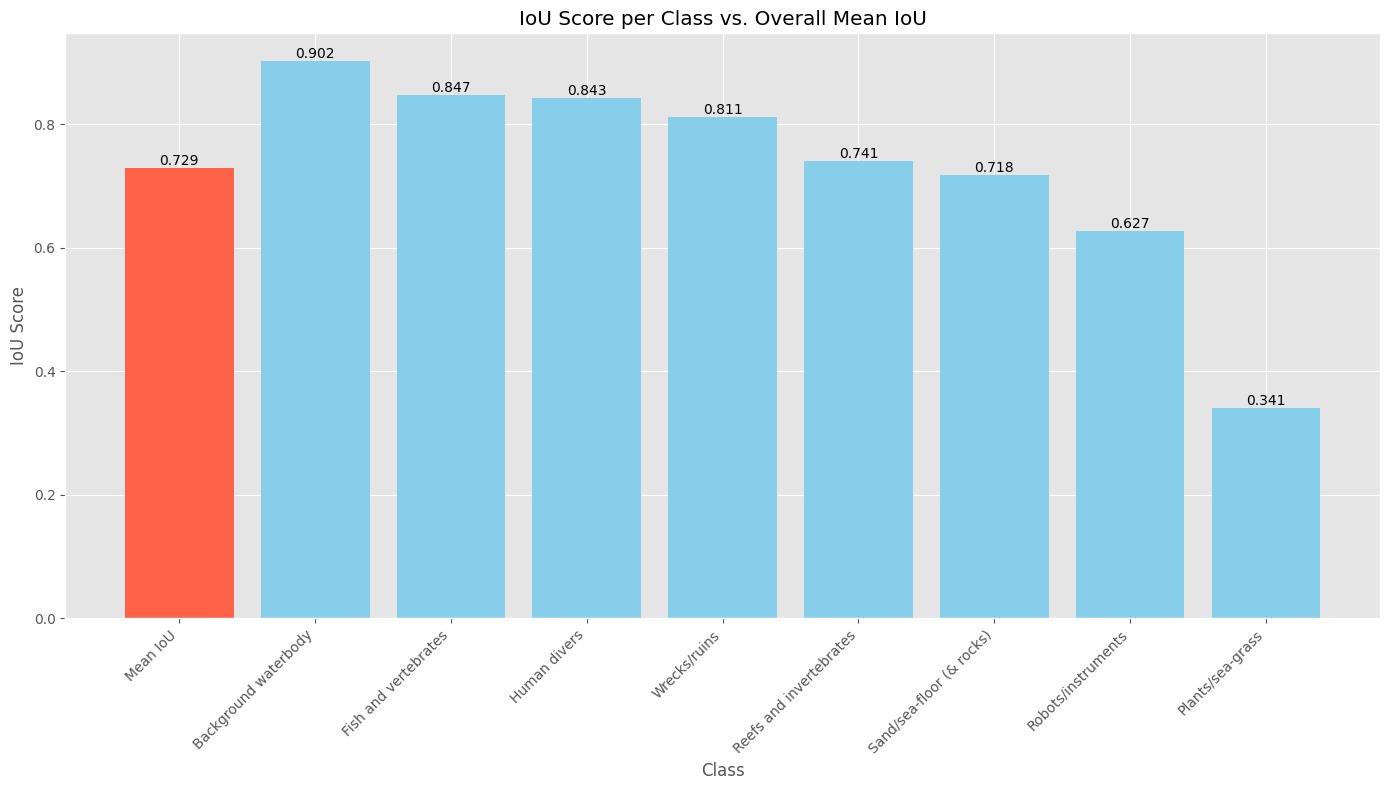

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import json

# Provided data
data = {
    "model_name": "dinov2_segformer_head",
    "pixel_accuracy": 0.8898178919294991,
    "mean_iou": 0.7287765224313709,
    "iou_per_class": {
        "Background waterbody": 0.9019757778217382,
        "Human divers": 0.8431169513937671,
        "Plants/sea-grass": 0.3407367188693011,
        "Wrecks/ruins": 0.8109680384201114,
        "Robots/instruments": 0.6271003727206864,
        "Reefs and invertebrates": 0.7410374188192448,
        "Fish and vertebrates": 0.8474678149412482,
        "Sand/sea-floor (& rocks)": 0.7178090864648698
    }
}

# --- Modification starts here ---

# Extract IoU per class and mean IoU
iou_data = data['iou_per_class']
mean_iou_value = data['mean_iou']

# Convert the dictionary of per-class IoU to a DataFrame
df_classes = pd.DataFrame(iou_data.items(), columns=['Class', 'IoU'])

# Sort per-class IoU by score in descending order
df_classes = df_classes.sort_values(by='IoU', ascending=False)

# Create a new DataFrame for the mean IoU value
mean_iou_df = pd.DataFrame([['Mean IoU', mean_iou_value]], columns=['Class', 'IoU'])

# Combine the mean IoU DataFrame with the per-class IoU DataFrame
# This places 'Mean IoU' as the first bar
df = pd.concat([mean_iou_df, df_classes], ignore_index=True)

# Create the bar chart
plt.style.use('ggplot')
plt.figure(figsize=(14, 8))

# Get the classes and IoU values for plotting
classes = df['Class']
iou_scores = df['IoU']

# Define colors for the bars. The first bar ('Mean IoU') will have a different color.
bar_colors = ['#FF6347'] + ['skyblue'] * (len(classes) - 1)

# Plot the bars with the specified colors
plt.bar(classes, iou_scores, color=bar_colors)

# Add text labels on top of each bar
for i, score in enumerate(iou_scores):
    plt.text(i, score, f'{score:.3f}', ha='center', va='bottom')

plt.xlabel('Class')
plt.ylabel('IoU Score')
plt.title('IoU Score per Class vs. Overall Mean IoU')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('iou_with_mean_bar_chart.png')
print("Bar chart saved as 'iou_with_mean_bar_chart.png'")


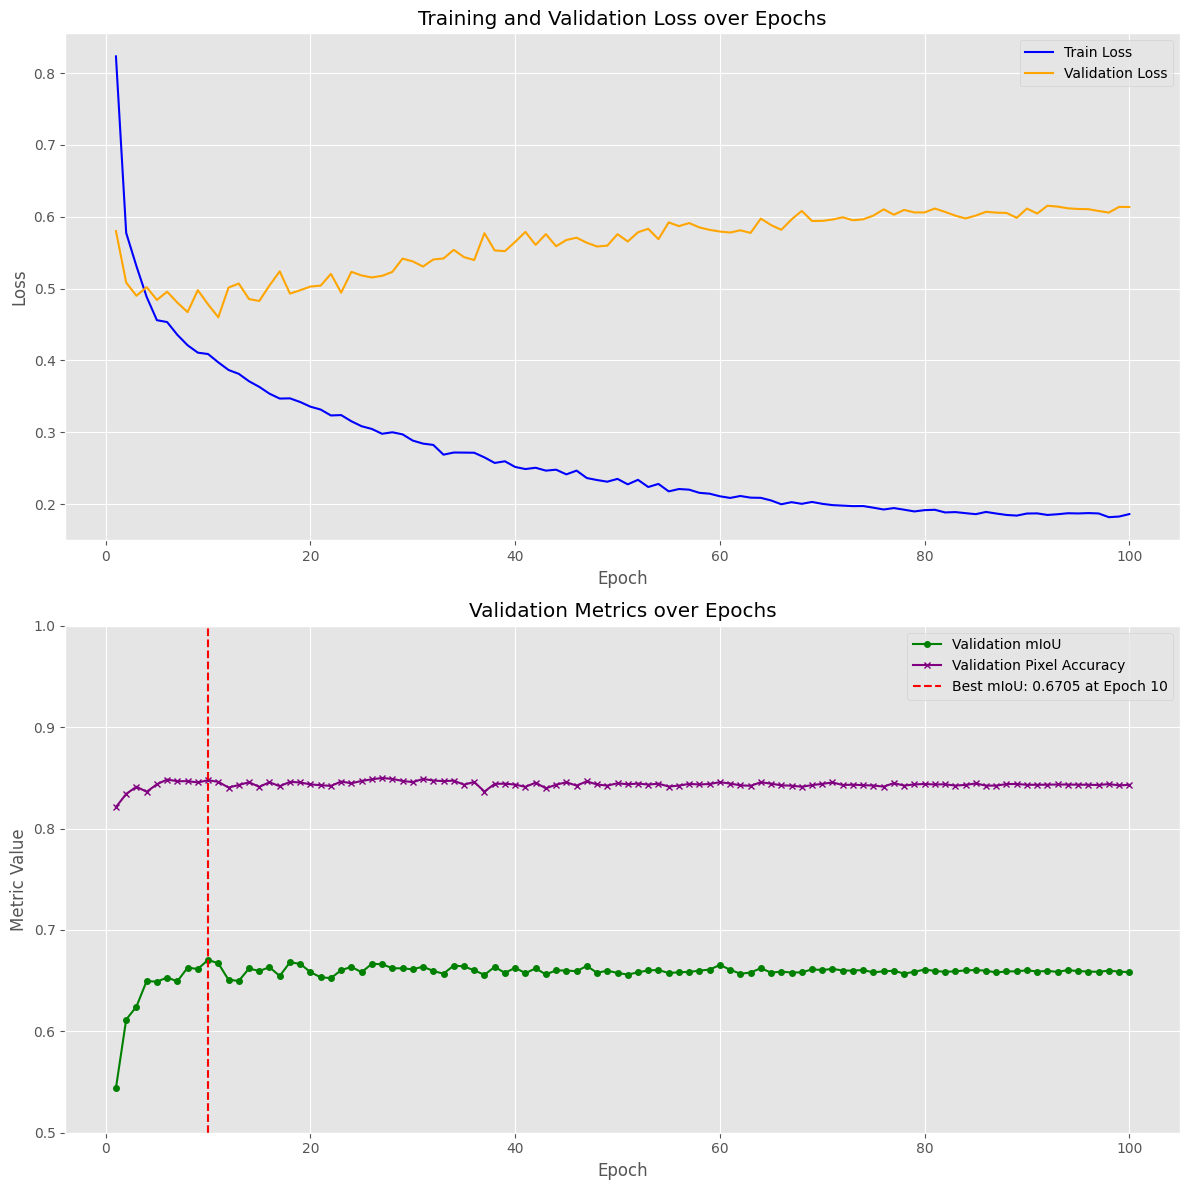

In [2]:
import re
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_logs(log_file_path):
    """
    Reads a training log file, parses the metrics, and plots them.

    Args:
        log_file_path (str): The path to the training log text file.
    """
    data = []
    # Regex pattern to capture the metrics from each epoch line
    log_pattern = re.compile(r'Epoch \[(\d+)/\d+\], Train Loss: ([\d.]+), Val Loss: ([\d.]+), Val mIoU: ([\d.]+), Val Pixel Acc: ([\d.]+)')

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = log_pattern.match(line.strip())
                if match:
                    # Extract values for each metric
                    epoch = int(match.group(1))
                    train_loss = float(match.group(2))
                    val_loss = float(match.group(3))
                    val_miou = float(match.group(4))
                    val_pixel_acc = float(match.group(5))
                    data.append([epoch, train_loss, val_loss, val_miou, val_pixel_acc])

        if not data:
            print(f"No matching log lines found in '{log_file_path}'. Please check the log format.")
            return

        # Create a pandas DataFrame from the extracted data
        df = pd.DataFrame(data, columns=['Epoch', 'Train Loss', 'Val Loss', 'Val mIoU', 'Val Pixel Acc'])

        # Find the epoch with the best mIoU
        best_miou_epoch = df.loc[df['Val mIoU'].idxmax()]

        # Create the plots
        plt.style.use('ggplot')
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 12))

        # Plot Loss
        ax1.plot(df['Epoch'], df['Train Loss'], label='Train Loss', color='blue')
        ax1.plot(df['Epoch'], df['Val Loss'], label='Validation Loss', color='orange')
        ax1.set_title('Training and Validation Loss over Epochs')
        ax1.set_xlabel('Epoch')
        ax1.set_ylabel('Loss')
        ax1.legend()
        ax1.grid(True)

        # Plot mIoU and Pixel Accuracy
        ax2.plot(df['Epoch'], df['Val mIoU'], label='Validation mIoU', color='green', marker='o', markersize=4)
        ax2.plot(df['Epoch'], df['Val Pixel Acc'], label='Validation Pixel Accuracy', color='purple', marker='x', markersize=4)
        ax2.axvline(x=best_miou_epoch['Epoch'], color='red', linestyle='--', label=f'Best mIoU: {best_miou_epoch["Val mIoU"]:.4f} at Epoch {int(best_miou_epoch["Epoch"])}')
        ax2.set_title('Validation Metrics over Epochs')
        ax2.set_xlabel('Epoch')
        ax2.set_ylabel('Metric Value')
        ax2.set_ylim(0.5, 1.0)
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

    except FileNotFoundError:
        print(f"Error: The file '{log_file_path}' was not found.")

# Specify the path to your log file
log_file = 'results/training_logs/dinov2_segformer_head_log_20250814-101232.txt' 

# Call the function with your file path
plot_training_logs(log_file)